Summary Statistics:
      Character Consistency              Story Coherence               \
                       mean median   std            mean median   std   
Comic                                                                   
A                      4.25    4.0  2.25            3.98    3.0  2.84   
B                      6.07    6.0  2.48            5.25    5.0  2.88   
C                      8.22    8.0  1.76            8.64    9.0  1.42   
D                      8.22    9.0  1.75            8.85    9.0  1.17   

      Adherence to Prompt              Image Quality               \
                     mean median   std          mean median   std   
Comic                                                               
A                    5.71    6.0  2.58          4.73    5.0  2.54   
B                    6.81    7.0  2.40          7.32    8.0  2.17   
C                    8.58    9.0  1.58          8.20    9.0  1.69   
D                    8.88    9.0  1.22          8.34  

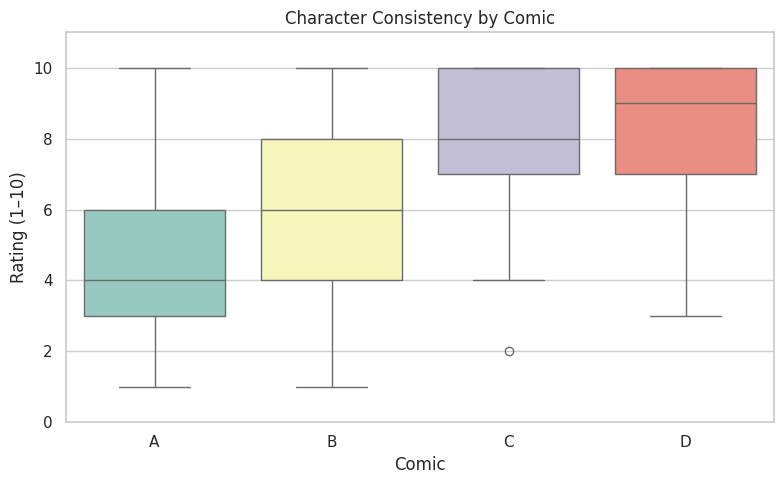

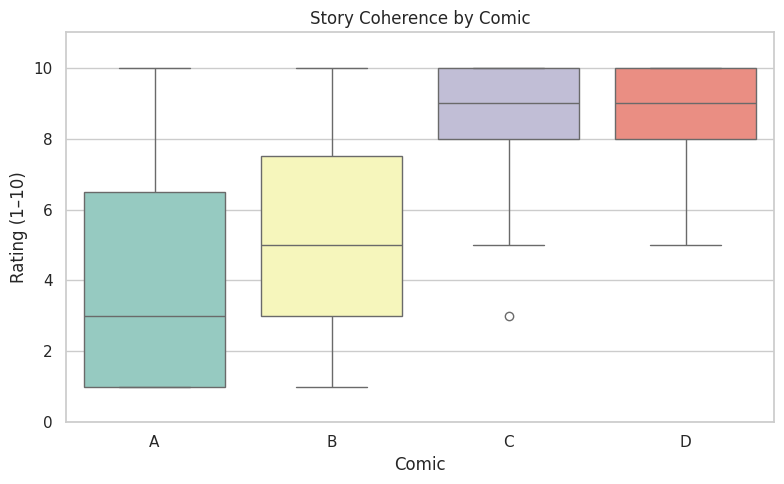

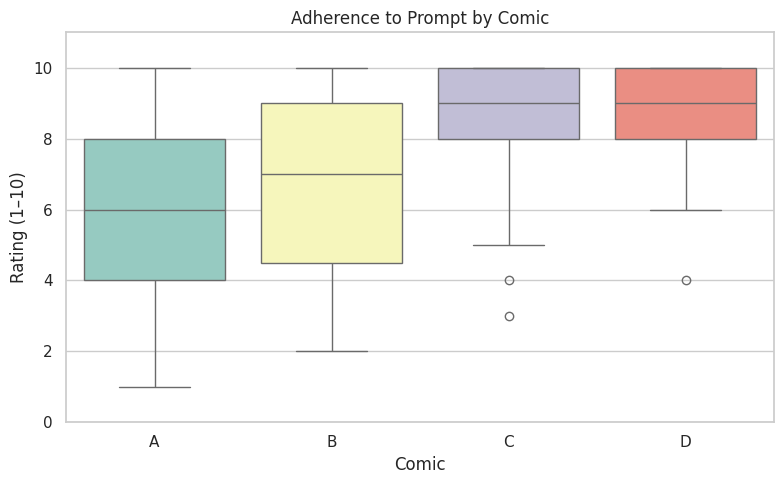

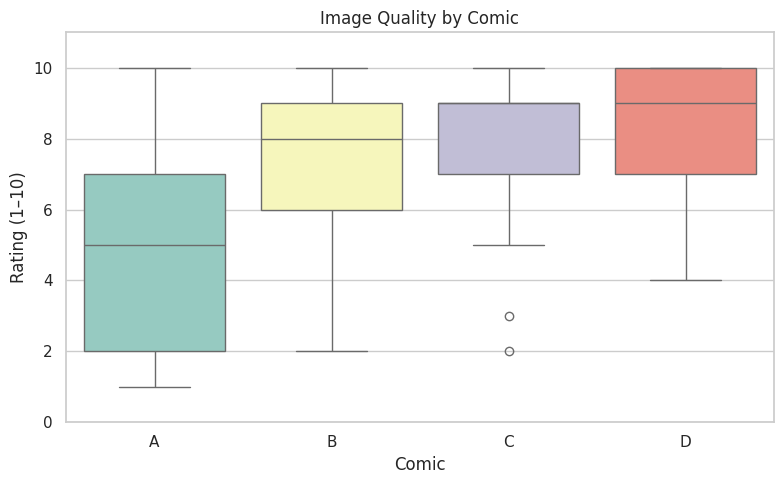

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load CSV
df = pd.read_csv("file.csv")

CRITERIA       = ["Character Consistency", "Story Coherence", "Adherence to Prompt", "Image Quality"]
FEEDBACK       = ["Please provide an explanation for your choices above."] * 4
COLS_PER_COMIC = 4 + 1  # 4 rating questions + 1 feedback question
COMICS         = ['A', 'B', 'C', 'D']

records = []
for idx, row in df.iterrows():
    for i, comic in enumerate(COMICS):
        offset = 9 + i * COLS_PER_COMIC  # offset starts after the consent form questions...
        ratings = {
            "Participant": idx + 1,
            "Comic": comic,
            "Character Consistency": row.iloc[offset],
            "Story Coherence": row.iloc[offset + 1],
            "Adherence to Prompt": row.iloc[offset + 2],
            "Image Quality": row.iloc[offset + 3],
            "Comment": row.iloc[offset + 4]
        }
        records.append(ratings)

long_df = pd.DataFrame(records)

# Convert rating columns to numeric
for col in CRITERIA:
    long_df[col] = pd.to_numeric(long_df[col], errors='coerce')

long_df.dropna(subset=CRITERIA, how='all', inplace=True)

# Summarise Statistics
summary = long_df.groupby("Comic")[CRITERIA].agg(['mean', 'median', 'std'])
low_score_pct = long_df[CRITERIA].lt(4).groupby(long_df['Comic']).mean() * 100
for criterion in CRITERIA:
    summary[(criterion, '% < 4')] = low_score_pct[criterion]
# Print Stats
print("Summary Statistics:")
print(summary.round(2))


# Plots
sns.set(style="whitegrid")
for criterion in CRITERIA:
    plt.figure(figsize=(8, 5))
    sns.boxplot(x="Comic", y=criterion, data=long_df, hue="Comic", palette="Set3", legend=False)
    plt.title(f"{criterion} by Comic")
    plt.ylim(0, 11)
    plt.ylabel("Rating (1–10)")
    plt.tight_layout()
    plt.show()

In [6]:
long_df["Average Rating"] = long_df[CRITERIA].mean(axis=1)

# Compute the mean of those averages per comic...
overall_avg = long_df.groupby("Comic")["Average Rating"].mean().round(2)

# Convert to a DataFrame for display
overall_avg_df = overall_avg.reset_index().rename(columns={"Average Rating": "Mean of All Criteria"})

print("Mean of all four criteria for each comic:")
print(overall_avg_df)



Mean of all four criteria for each comic:
  Comic  Mean of All Criteria
0     A                  4.67
1     B                  6.36
2     C                  8.41
3     D                  8.57


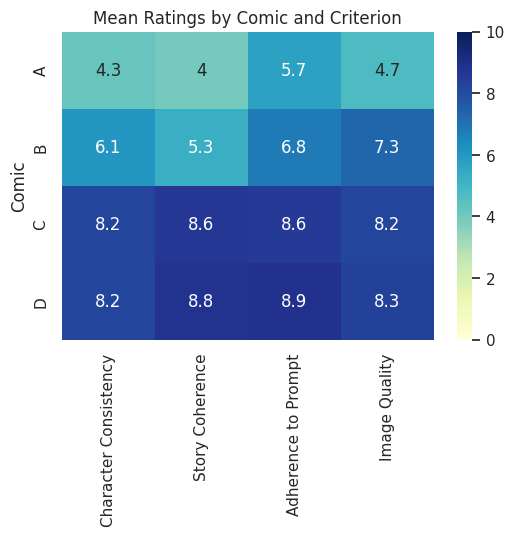

In [4]:
plt.figure(figsize=(6, 4))
sns.heatmap(long_df.groupby("Comic")[CRITERIA].mean(), annot=True, cmap="YlGnBu", vmin=0, vmax=10)
plt.title("Mean Ratings by Comic and Criterion")
plt.show()

In [5]:
for comic in COMICS:
    print(f"====== SAMPLE COMMENTS FOR COMIC {comic}: =====")
    comments = long_df[long_df['Comic'] == comic]['Comment'].dropna()
    for c in comments:
        print(f"- {c}")


====== SAMPLE COMMENTS FOR COMIC A: =====
- the images are random and don't have a proper storyline. There is no consistency in the characters between panels.
- The image adheres to the prompt and is of good quality considering comic strips. It seems decently coherent. 
- The image is not properly alligned and is difficult to understand the context and story telling part through this image.
- The image is not looking properly aligned 
- The image is good and story is alright but I think the details could be better and clearer
- The image is unaligned and faces are blurred and there is nothing going on, books look weird, no text
- 1. Two different female characters
2. Unrecognizable face
3. Still did take place in a library
- she looks different in both strips and doesn’t seem like it is a story, more just like 2 separate occasions
- Clearly, the image generated is not at all of good quality and proper adherence to prompt is missing 
- The image is unclear and hard to interpret. 
- The 